In [201]:
import numpy as np
from scipy.sparse.linalg import spsolve
import scipy.sparse as sp
import matplotlib.pyplot as plt
import cmocean

In [202]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
})
plt.style.use('seaborn-v0_8-colorblind')
# Set the global font size
plt.rcParams['font.size'] = 14

# Problem 1

In [203]:
def periodic_second_difference(n, h):
    """1D second derivative with periodic endpoints."""
    D = sp.diags(
        [np.ones(n - 1), -2 * np.ones(n), np.ones(n - 1)],
        offsets=[-1, 0, 1],
        shape=(n, n),
        format="lil",
    ) / h**2

    D[0, -1] = 1 / h**2
    D[-1, 0] = 1 / h**2

    return D.tocsr()

def create_u_laplacian(nx, ny, xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0):
    """
    Laplacian on the U grid.

    U is periodic in x and has U = 0 at the top/bottom walls.
    U contains nx * ny unknowns.
    """

    hx = (xmax - xmin) / nx
    hy = (ymax - ymin) / ny

    Dxx = periodic_second_difference(nx, hx)

    Dyy = sp.diags(
        [np.ones(ny - 1), -2 * np.ones(ny), np.ones(ny - 1)],
        offsets=[-1, 0, 1],
        shape=(ny, ny),
        format="lil",
    ) / hy**2

    # Ghost-cell treatment for U = 0 at y = ymin and y = ymax.
    Dyy[0, 0] = -3 / hy**2
    Dyy[-1, -1] = -3 / hy**2

    # 2D Laplacian : L = I_y (x) Dx + Dy (x) I_x
    Ix = sp.eye(nx)
    Iy = sp.eye(ny)
    L = sp.kron(Iy, Dxx, format="csr") + sp.kron(Dyy, Ix, format="csr")

    return L

def create_v_laplacian(nx, ny, v_bottom=-3.5, v_top=-3.5, xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0):
    """
    Laplacian on interior V-grid unknowns.

    V is periodic in x. Its values on y = ymin and y = ymax are known,
    so they are excluded from the unknown vector and returned as RHS terms.
    """

    hx = (xmax - xmin) / nx
    hy = (ymax - ymin) / ny
    ny_v = ny-1

    Dxx = periodic_second_difference(nx, hx)

    Dyy = sp.diags(
        [np.ones(ny_v - 1), -2 * np.ones(ny_v), np.ones(ny_v - 1)],
        offsets=[-1, 0, 1],
        shape=(ny_v, ny_v),
        format="csr",
    ) / hy**2

    # The boundary V values are eliminated and placed in the RHS.
    # 2D Laplacian : L = I_y (x) Dx + Dy (x) I_x
    Ix = sp.eye(nx, format="csr")
    Iy = sp.eye(ny_v, format="csr")
    L = sp.kron(Iy, Dxx, format="csr") + sp.kron(Dyy, Ix, format="csr")

    # Terms moved from the left-hand side into the V-momentum RHS.
    v_boundary_rhs = np.zeros(nx * ny_v)
    v_boundary_rhs[:nx] -= v_bottom / hy**2
    v_boundary_rhs[-nx:] -= v_top / hy**2

    return L, v_boundary_rhs

def create_gradient_divergence(
    nx,
    ny,
    v_bottom=-3.5,
    v_top=-3.5,
    xmin=0.0,
    xmax=1.0,
    ymin=0.0,
    ymax=1.0,
):
    """
    Build MAC-grid gradient and divergence operators.
    """
    hx = (xmax - xmin) / nx
    hy = (ymax - ymin) / ny

    Ix = sp.eye(nx, format="csr")
    Iy = sp.eye(ny, format="csr")

    # Gx maps P values to U-face x-gradients:
    # (P[i, j] - P[i - 1, j]) / hx
    Gx_1d = sp.diags(
        [-np.ones(nx - 1), np.ones(nx)],
        offsets=[-1, 0],
        shape=(nx, nx),
        format="lil",
    )
    Gx_1d[0, -1] = -1  # Periodic pressure value to the left of i = 0.
    Gx_1d = Gx_1d.tocsr() / hx

    Gx = sp.kron(Iy, Gx_1d, format="csr")

    # Gy maps P values to interior V-face y-gradients:
    # (P[i, j] - P[i, j - 1]) / hy
    #
    # Row 0 corresponds to V at physical y-index j = 1.
    Gy_1d = sp.diags(
        [-np.ones(ny - 1), np.ones(ny - 1)],
        offsets=[0, 1],
        shape=(ny - 1, ny),
        format="csr",
    ) / hy

    Gy = sp.kron(Gy_1d, Ix, format="csr")

    # Compatible discrete divergence operators.
    Dx = -Gx.T.tocsr()
    Dy = -Gy.T.tocsr()

    # Boundary contribution to D_x U + D_y V = h_bc.
    #
    # V at the bottom/top boundaries is known and excluded from
    # the V unknown vector, so its contribution moves to the RHS.
    h_bc = np.zeros(nx * ny)
    h_bc[:nx] += v_bottom / hy
    h_bc[-nx:] -= v_top / hy

    return Gx, Gy, Dx, Dy, h_bc

In [204]:
# define given functions

mu = 1
pi = np.pi
U = lambda x, y: np.sin(2 * pi * y) * np.sin(2 * pi * x)
V = lambda x, y: -3.5 + np.cos(2 * pi * x) * (np.cos(2 * pi * y) - 1)
P = lambda x, y: np.sin(2 * pi * y) * np.cos(2 * pi * x)

f = lambda x, y: (-8 * pi**2 + 2 * pi) * np.sin(2 * pi * y) * np.sin(2 * pi * x)
g = lambda x, y: np.cos(2 * pi * x) * (-1 * (8 * pi**2 + 2 * pi) * np.cos(2 * pi * y) + 4 * pi**2)


In [205]:
# Grid, operators, and manufactured right-hand side.
def stokes_solver(n, v_bndry_top, v_bndry_bottom, min, max):
    data = {}
    nx = ny = n
    xmin = ymin = min
    xmax = ymax = max

    hx = (xmax - xmin) / nx
    hy = (ymax - ymin) / ny
    data["hx"] = hx
    data["hy"] = hy
    data["xmin"] = xmin
    data["xmax"] = xmax
    data["ymin"] = ymin
    data["ymax"] = ymax

    x_v = xmin + (np.arange(nx) + 0.5) * hx
    v_top = v_bndry_top(x_v)
    v_bottom = v_bndry_bottom(x_v)

    L_u = create_u_laplacian(nx, ny, xmin, xmax, ymin, ymax)
    L_v, v_boundary_rhs = create_v_laplacian(
        nx, ny, v_bottom, v_top, xmin, xmax, ymin, ymax
    )
    Gx, Gy, Dx, Dy, h_bc = create_gradient_divergence(
        nx, ny, v_bottom, v_top, xmin, xmax, ymin, ymax
    )

    # Fast index x
    x_u = xmin + np.arange(nx) * hx
    y_u = ymin + (np.arange(ny) + 0.5) * hy
    X_u, Y_u = np.meshgrid(x_u, y_u, indexing="xy")
    u_an = U(X_u, Y_u)

    y_v = ymin + np.arange(1, ny) * hy
    X_v, Y_v = np.meshgrid(x_v, y_v, indexing="xy")
    v_an = V(X_v, Y_v)

    x_p = x_v
    y_p = y_u
    X_p, Y_p = np.meshgrid(x_p, y_p, indexing="xy")
    p_an = P(X_p, Y_p)

    error_data = {}

    error_data["u_an"] = u_an
    error_data["v_an"] = v_an
    error_data["p_an"] = p_an


    data["x_p"] = x_p
    data["y_p"] = y_p
    data["X_p"] = X_p
    data["Y_p"] = Y_p

    f_bc = f(X_u, Y_u).ravel()
    g_bc = g(X_v, Y_v).ravel() + v_boundary_rhs

    n_u = nx * ny
    n_v = nx * (ny - 1)
    n_p = nx * ny

    lhs = sp.bmat(
        [[L_u, None, -Gx], [None, L_v, -Gy], [Dx, Dy, None]],
        format="csr",
    )
    rhs = np.concatenate([f_bc, g_bc, h_bc])

    # The pressure is determined only up to a constant. Pin one divergence row with 
    # P[0] = 0 so the sparse direct solve is nonsingular.
    pressure_row = n_u + n_v
    lhs_gauged = lhs.tolil()
    lhs_gauged.rows[pressure_row] = [pressure_row]
    lhs_gauged.data[pressure_row] = [1.0]
    rhs_gauged = rhs.copy()
    rhs_gauged[pressure_row] = 0.0
    solution = spsolve(lhs_gauged.tocsc(), rhs_gauged)

    u_num = solution[:n_u].reshape(ny, nx)
    v_num = solution[n_u:n_u + n_v].reshape(ny - 1, nx)
    p_num = solution[n_u + n_v:].reshape(ny, nx)
    p_num -= p_num.mean()
    error_data["u_num"] = u_num
    error_data["v_num"] = v_num
    error_data["p_num"] = p_num


    # Restore known V boundary values before averaging velocities to cell centers.
    v_faces = np.empty((ny + 1, nx))
    v_faces[0, :] = v_bottom
    v_faces[-1, :] = v_top
    v_faces[1:-1, :] = v_num
    # average velocity to cell centers (same physical location)
    u_center = 0.5 * (u_num + np.roll(u_num, -1, axis=1))
    v_center = 0.5 * (v_faces[:-1, :] + v_faces[1:, :])
    speed = np.hypot(u_center, v_center)
    data["u_center"] = u_center
    data["v_center"] = v_center
    data["speed"] = speed

    # Structural and solution checks.
    assert L_u.shape == (n_u, n_u)
    assert L_v.shape == (n_v, n_v)
    assert Gx.shape == (n_u, n_p) and Gy.shape == (n_v, n_p)
    assert Dx.shape == (n_p, n_u) and Dy.shape == (n_p, n_v)
    assert (Dx + Gx.T).nnz == 0 and (Dy + Gy.T).nnz == 0
    # assert np.allclose(v_faces[[0, -1], :], -3.5)
    assert speed.shape == (ny, nx) and np.isfinite(speed).all()

    full_residual = lhs @ solution - rhs
    divergence_residual = Dx @ u_num.ravel() + Dy @ v_num.ravel() - h_bc
    relative_residual = np.linalg.norm(full_residual) / np.linalg.norm(rhs)

    # print(f"Relative system residual: {relative_residual:.2e}")
    # print(f"Divergence residual: {np.linalg.norm(divergence_residual):.2e}")

    return data, error_data


In [206]:
v_bndry = lambda x: -3.5
n = 128
data, _ = stokes_solver(n, v_bndry, v_bndry, 0.0, 1.0)

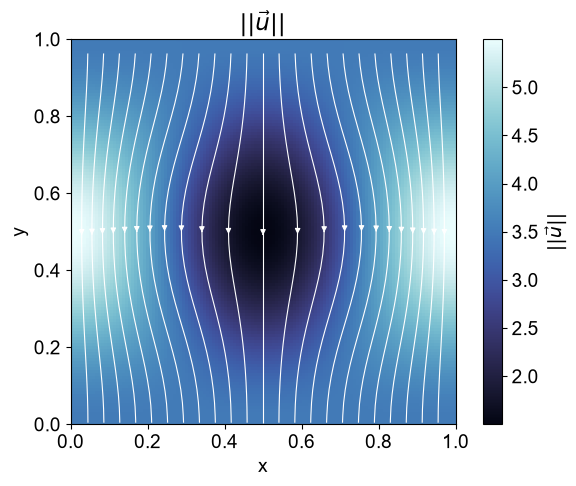

In [207]:
plt.figure(figsize=(7, 5))
image = plt.pcolormesh(data["X_p"], data["Y_p"], data["speed"], shading="auto", cmap=cmocean.cm.ice)

num_streamlines = 25

start_points = np.column_stack(
    [
        np.linspace(data["xmin"] + 0.5 * data["hx"], data["xmax"] - 0.5 * data["hx"], num_streamlines),
        np.full(num_streamlines, data["ymax"] - 0.5 * data["hy"]),
    ]
)

plt.streamplot(
    data["x_p"],
    data["y_p"],
    data["u_center"],
    data["v_center"],
    start_points=start_points,
    integration_direction="forward",
    broken_streamlines=False,
    color="white",
    linewidth=0.8,
    arrowsize=0.8,
    arrowstyle="-|>",
)

plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$||\vec{u}||$")
plt.colorbar(image, label=r"$||\vec{u}||$")
plt.show()

# Problem 2

In [208]:
N_values = np.linspace(10, 100, 10)
error_u = np.empty(len(N_values))
error_v = np.empty(len(N_values))
error_p = np.empty(len(N_values))

for index, N in enumerate(N_values):
    _, error_data = stokes_solver(int(N), v_bndry, v_bndry, 0.0, 1.0)
    u_num = error_data["u_num"]
    v_num = error_data["v_num"]
    p_num = error_data["p_num"]
    u_an = error_data["u_an"]
    v_an = error_data["v_an"]
    p_an = error_data["p_an"]
    
    error_u[index] = np.linalg.norm(u_num - u_an) / np.linalg.norm(u_an)
    error_v[index] = np.linalg.norm(v_num - v_an) / np.linalg.norm(v_an)
    error_p[index] = np.linalg.norm(p_num - p_an) / np.linalg.norm(p_an)

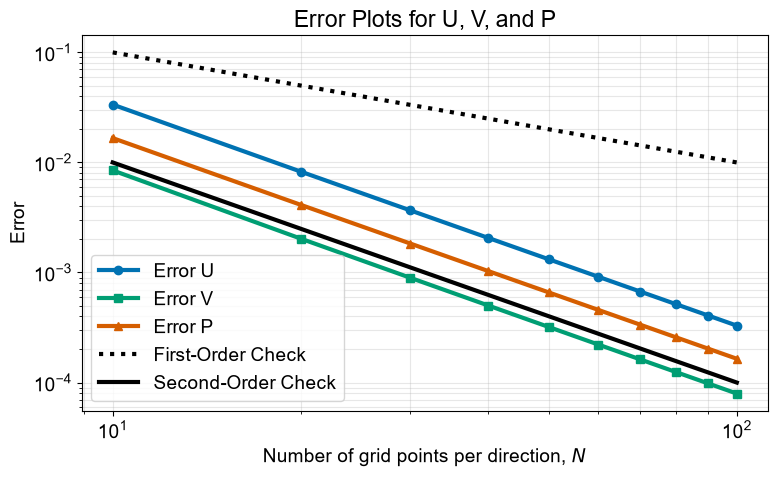

In [209]:
first_order = 0.1 * (N_values[0] / N_values)
second_order = 0.01 * (N_values[0] / N_values) ** 2

plt.figure(figsize=(8, 5))
plt.loglog(N_values, error_u, "o-", label=r"Error U", linewidth=3)
plt.loglog(N_values, error_v, "s-", label=r"Error V", linewidth=3)
plt.loglog(N_values, error_p, "^-", label=r"Error P", linewidth=3)
plt.loglog(N_values, first_order, "k:", label=r"First-Order Check", linewidth=3)
plt.loglog(N_values, second_order, "k", label=r"Second-Order Check", linewidth=3)
plt.xlabel(r"Number of grid points per direction, $N$")
plt.ylabel("Error")
plt.title("Error Plots for U, V, and P")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Problem 3

Test flow with different V boundary values

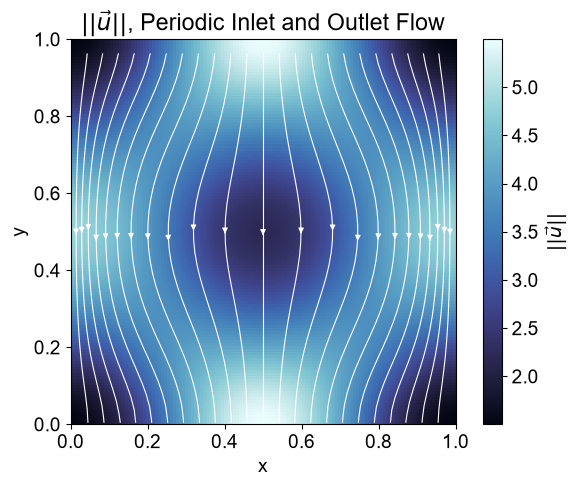

In [210]:
v_bndry_new = lambda x: -3.5 + 2*np.cos(2 * pi * x)
# v_bndry_new = lambda x: np.cos( pi * x)
n = 128
min = 0.0
max = 1.0
new_data, _ = stokes_solver(n, v_bndry_new, v_bndry_new, min, max)

plt.figure(figsize=(7, 5))
image = plt.pcolormesh(new_data["X_p"], new_data["Y_p"], new_data["speed"], shading="auto", cmap=cmocean.cm.ice)

num_streamlines = 25

start_points = np.column_stack(
    [
        np.linspace(new_data["xmin"] + 0.5 * new_data["hx"], new_data["xmax"] - 0.5 * new_data["hx"], num_streamlines),
        np.full(num_streamlines, new_data["ymax"] - 0.5 * new_data["hy"]),
    ]
)

plt.streamplot(
    new_data["x_p"],
    new_data["y_p"],
    new_data["u_center"],
    new_data["v_center"],
    start_points=start_points,
    integration_direction="forward",
    broken_streamlines=False,
    color="white",
    linewidth=0.8,
    arrowsize=0.8,
    arrowstyle="-|>",
)

plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$||\vec{u}||$, Periodic Inlet and Outlet Flow")
plt.colorbar(image, label=r"$||\vec{u}||$")
plt.show()

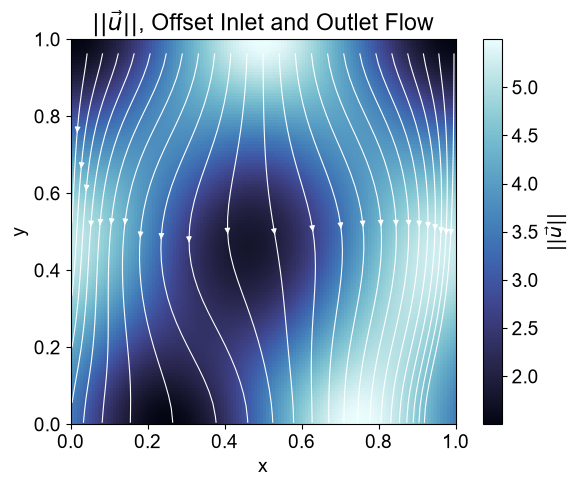

In [211]:
v_bndry_top = lambda x: -3.5 + 2*np.cos(2 * pi * x)
v_bndry_bottom = lambda x: -3.5 + 2*np.sin(2 * pi * x)

n = 128
min = 0.0
max = 1.0
new_data, _ = stokes_solver(n, v_bndry_top, v_bndry_bottom, min, max)

plt.figure(figsize=(7, 5))
image = plt.pcolormesh(new_data["X_p"], new_data["Y_p"], new_data["speed"], shading="auto", cmap=cmocean.cm.ice)

num_streamlines = 25

start_points = np.column_stack(
    [
        np.linspace(new_data["xmin"] + 0.5 * new_data["hx"], new_data["xmax"] - 0.5 * new_data["hx"], num_streamlines),
        np.full(num_streamlines, new_data["ymax"] - 0.5 * new_data["hy"]),
    ]
)

plt.streamplot(
    new_data["x_p"],
    new_data["y_p"],
    new_data["u_center"],
    new_data["v_center"],
    start_points=start_points,
    integration_direction="forward",
    broken_streamlines=False,
    color="white",
    linewidth=0.8,
    arrowsize=0.8,
    arrowstyle="-|>",
)

plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$||\vec{u}||$, Offset Inlet and Outlet Flow")
plt.colorbar(image, label=r"$||\vec{u}||$")
plt.show()

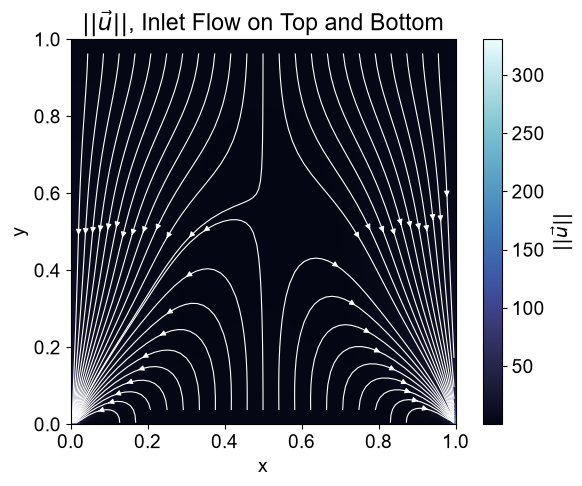

In [212]:
v_bndry_top = lambda x: -3.5
v_bndry_bottom = lambda x: 3.5

n = 128
min = 0.0
max = 1.0
new_data, _ = stokes_solver(n, v_bndry_top, v_bndry_bottom, min, max)

plt.figure(figsize=(7, 5))
image = plt.pcolormesh(new_data["X_p"], new_data["Y_p"], new_data["speed"], shading="auto", cmap=cmocean.cm.ice)

num_streamlines = 25

start_points = np.column_stack(
    [
        np.linspace(new_data["xmin"] + 0.5 * new_data["hx"], new_data["xmax"] - 0.5 * new_data["hx"], num_streamlines),
        np.full(num_streamlines, new_data["ymax"] - 0.5 * new_data["hy"]),
    ]
)

plt.streamplot(
    new_data["x_p"],
    new_data["y_p"],
    new_data["u_center"],
    new_data["v_center"],
    start_points=start_points,
    integration_direction="forward",
    broken_streamlines=False,
    color="white",
    linewidth=0.8,
    arrowsize=0.8,
    arrowstyle="-|>",
)

plt.streamplot(
    new_data["x_p"],
    new_data["y_p"],
    new_data["u_center"],
    new_data["v_center"],
    start_points=1-start_points,
    integration_direction="forward",
    broken_streamlines=False,
    color="white",
    linewidth=0.8,
    arrowsize=0.8,
    arrowstyle="-|>",
)

plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$||\vec{u}||$, Inlet Flow on Top and Bottom")
plt.colorbar(image, label=r"$||\vec{u}||$")
plt.show()